eda_first_part

In [1]:
import pandas as pd

# =========================
# 1) Chargement
# =========================
DATA_PATH = "data/train.csv"
df = pd.read_csv(DATA_PATH)

print("\n=== Aperçu ===")
print(df.head())

print("\n=== Shape ===")
print(df.shape)

print("\n=== Types de variables ===")
print(df.dtypes)

print("\n=== Infos générales ===")
print(df.info())

print("\n=== Valeurs manquantes (%) ===")
missing_pct = df.isna().mean() * 100
print(missing_pct.sort_values(ascending=False))

print("\n=== Statistiques descriptives (numériques) ===")
print(df.describe())



=== Aperçu ===
                               Name    Location  Year  Kilometers_Driven  \
0            Maruti Wagon R LXI CNG      Mumbai  2010              72000   
1  Hyundai Creta 1.6 CRDi SX Option        Pune  2015              41000   
2                      Honda Jazz V     Chennai  2011              46000   
3                 Maruti Ertiga VDI     Chennai  2012              87000   
4   Audi A4 New 2.0 TDI Multitronic  Coimbatore  2013              40670   

  Fuel_Type Transmission Owner_Type     Mileage   Engine      Power  Seats  \
0       CNG       Manual      First  26.6 km/kg   998 CC  58.16 bhp    5.0   
1    Diesel       Manual      First  19.67 kmpl  1582 CC  126.2 bhp    5.0   
2    Petrol       Manual      First   18.2 kmpl  1199 CC   88.7 bhp    5.0   
3    Diesel       Manual      First  20.77 kmpl  1248 CC  88.76 bhp    7.0   
4    Diesel    Automatic     Second   15.2 kmpl  1968 CC  140.8 bhp    5.0   

   New_Price  Price  
0        NaN   1.75  
1        NaN  

Analyse univariée (variable par variable)

C:\Users\joachim.querule\AppData\Local\Temp\ipykernel_22196\2007350821.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object", "category"]).columns


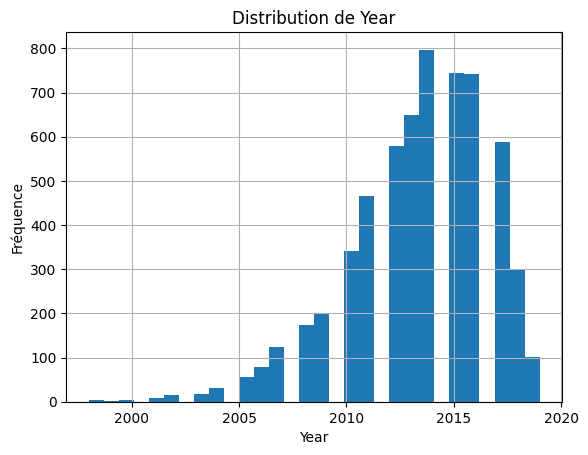

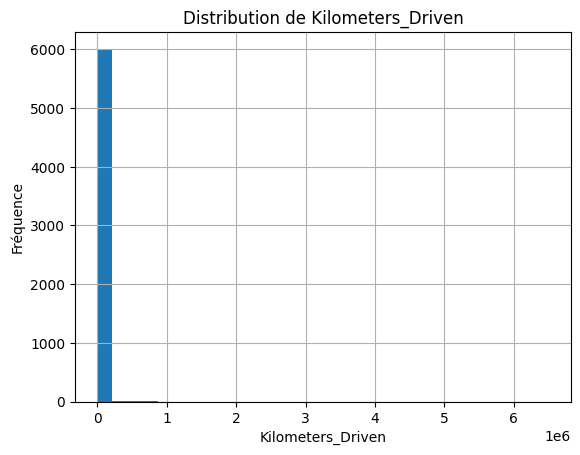

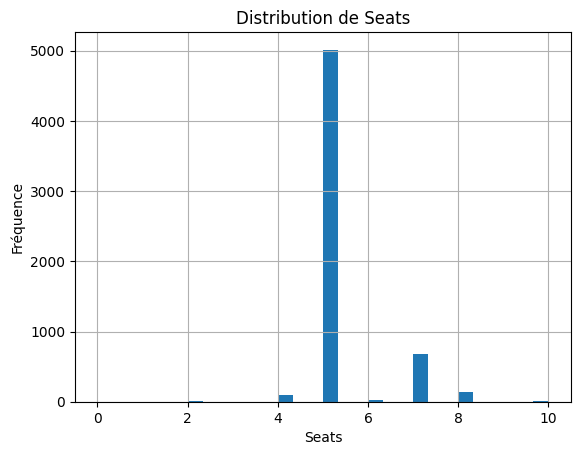

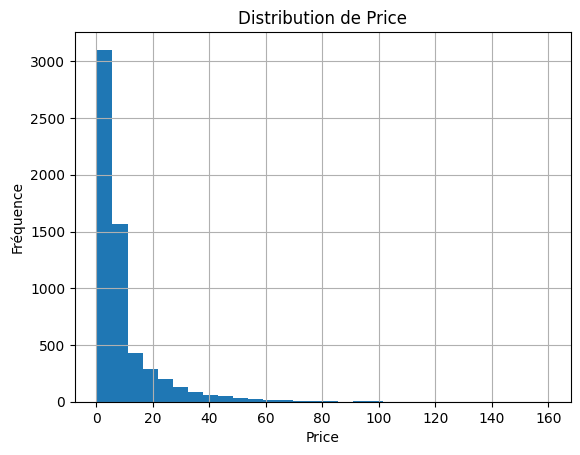


=== Name ===
Name
Mahindra XUV500 W8 2WD        0.008141
Maruti Swift VDI              0.007476
Honda City 1.5 S MT           0.005649
Maruti Swift Dzire VDI        0.005649
Maruti Swift VDI BSIV         0.005150
Maruti Ritz VDi               0.004984
Hyundai i10 Sportz            0.004984
Toyota Fortuner 3.0 Diesel    0.004818
Honda Amaze S i-Dtech         0.004486
Hyundai Grand i10 Sportz      0.004486
Name: proportion, dtype: float64

=== Location ===
Location
Mumbai        0.131251
Hyderabad     0.123276
Kochi         0.108158
Coimbatore    0.105665
Pune          0.103339
Delhi         0.092042
Kolkata       0.088885
Chennai       0.082073
Jaipur        0.068616
Bangalore     0.059478
Name: proportion, dtype: float64

=== Fuel_Type ===
Fuel_Type
Diesel      0.532480
Petrol      0.456222
CNG         0.009304
LPG         0.001661
Electric    0.000332
Name: proportion, dtype: float64

=== Transmission ===
Transmission
Manual       0.714238
Automatic    0.285762
Name: proportion, dtyp

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/train.csv")

num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object", "category"]).columns

# =========================
# Numériques
# =========================
for col in num_cols:
    plt.figure()
    df[col].hist(bins=30)
    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.show()

# =========================
# Catégorielles
# =========================
for col in cat_cols:
    print(f"\n=== {col} ===")
    print(df[col].value_counts(normalize=True).head(10))


Analyse bivariée (relations)

<Figure size 640x480 with 0 Axes>

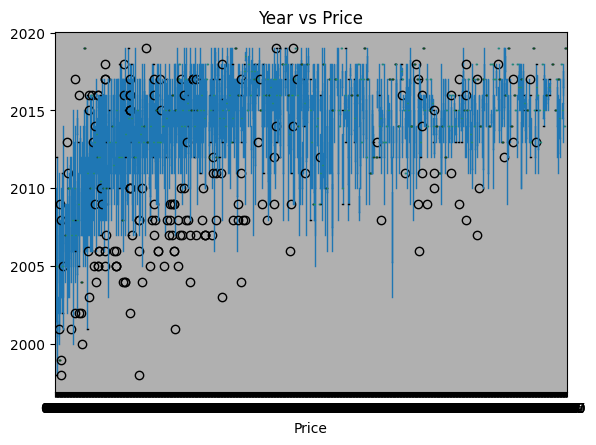

<Figure size 640x480 with 0 Axes>

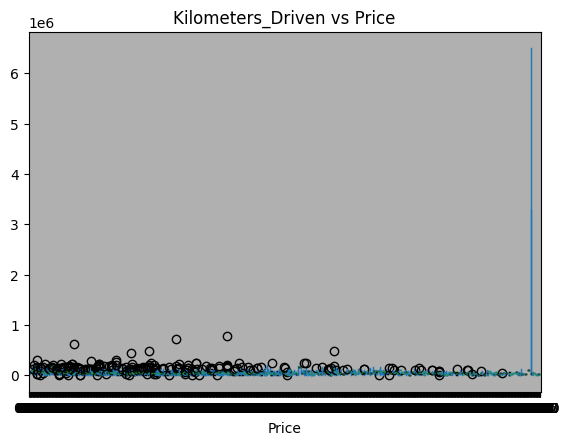

<Figure size 640x480 with 0 Axes>

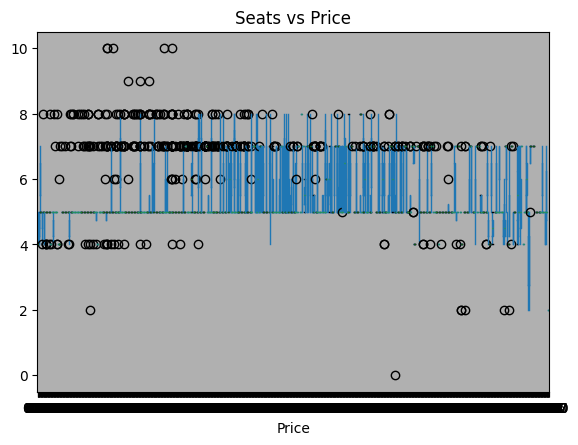

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/train.csv")

# ⚠️ adapte le nom de la target si besoin
TARGET = "Price" if "Price" in df.columns else None

if TARGET:
    num_cols = df.select_dtypes(include=["int64", "float64"]).columns.drop(TARGET)

    for col in num_cols:
        plt.figure()
        df.boxplot(column=col, by=TARGET)
        plt.title(f"{col} vs {TARGET}")
        plt.suptitle("")
        plt.show()
else:
    print("⚠️ Aucune variable cible détectée")


corrélation , valeures manquantes 

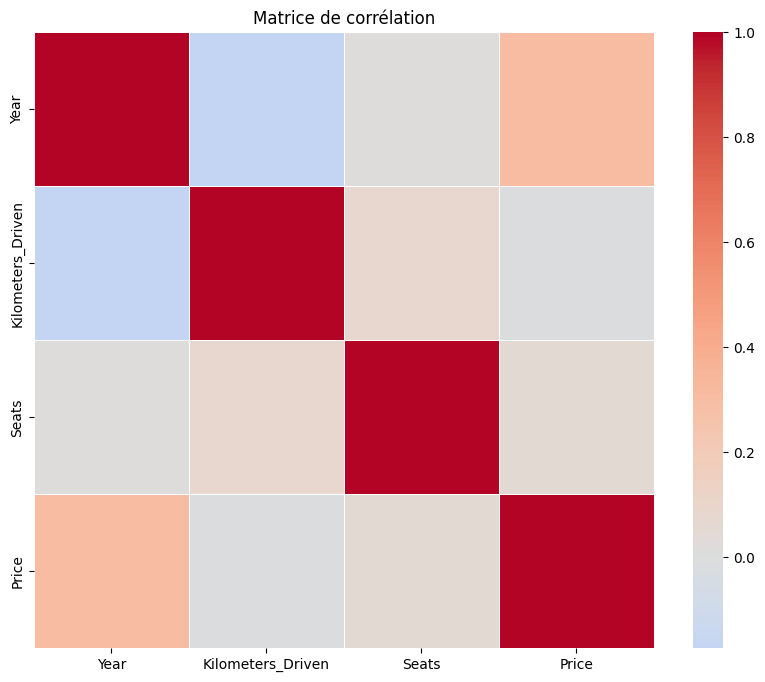

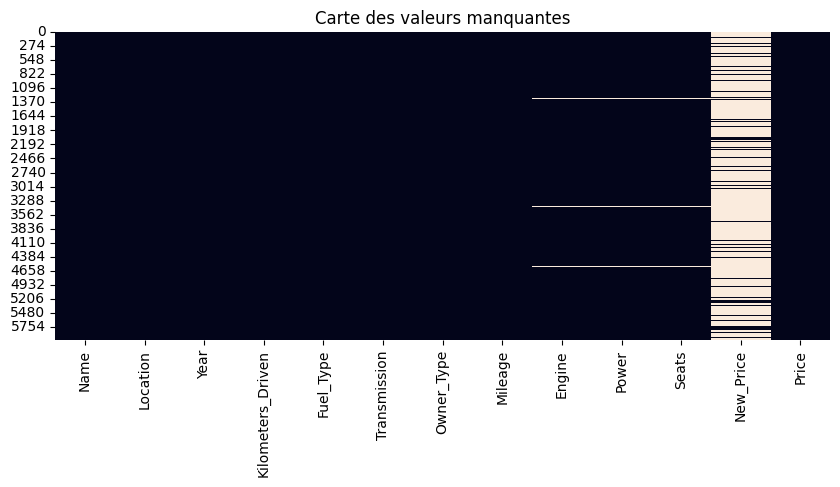

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/train.csv")

num_df = df.select_dtypes(include=["int64", "float64"])

# =========================
# Matrice de corrélation
# =========================
plt.figure(figsize=(10, 8))
sns.heatmap(
    num_df.corr(),
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Matrice de corrélation")
plt.show()

# =========================
# Visualisation des NaN
# =========================
plt.figure(figsize=(10, 4))
sns.heatmap(df.isna(), cbar=False)
plt.title("Carte des valeurs manquantes")
plt.show()
